# RQ1: Individual Influential Factors in Trend Classification (ML Dataset)

**Research question:** What factors, such as platform, region, content category, traffic source, and engagement metrics, most strongly influence video trend classification?


## 1. Load ML Processed Data

The ML preprocessing notebook already cleaned missing values, encoded categorical variables, and saved numeric train/validation/test files.


In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, f1_score

train = pd.read_csv("../data/processed_ml/train.csv")
validation = pd.read_csv("../data/processed_ml/validation.csv")
test = pd.read_csv("../data/processed_ml/test.csv")
feature_metadata = pd.read_csv("../data/processed_ml/feature_metadata.csv")

TARGET = "trend_label"

X_train = train.drop(columns=TARGET)
y_train = train[TARGET]

X_val = validation.drop(columns=TARGET)
y_val = validation[TARGET]

X_test = test.drop(columns=TARGET)
y_test = test[TARGET]

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

display(y_train.value_counts(normalize=True).sort_index())
display(feature_metadata.head())

Train: (35000, 72) (35000,)
Validation: (7500, 72) (7500,)
Test: (7500, 72) (7500,)


trend_label
declining    0.101971
rising       0.250000
seasonal     0.094114
stable       0.553914
Name: proportion, dtype: float64

,feature,original_feature,feature_group
0,title_len,title_len,content_basic
1,text_richness,text_richness,content_basic
2,like_rate,like_rate,engagement_observed
3,comment_rate,comment_rate,engagement_observed
4,share_rate,share_rate,engagement_observed


## 2. Feature Inventory


In [2]:
feature_inventory = pd.DataFrame([
    {
        "feature": column,
        "dtype": str(X_train[column].dtype),
        "missing_rate": X_train[column].isna().mean(),
        "n_unique": X_train[column].nunique(dropna=True),
    }
    for column in X_train.columns
]).sort_values("n_unique", ascending=True)

print("Number of model features:", len(feature_inventory))
display(feature_inventory.head(50))

Number of model features: 72


,feature,dtype,missing_rate,n_unique
0,title_len,int64,0.0,2
1,text_richness,float64,0.0,2
15,platform_cat,int64,0.0,2
27,region_americas,int64,0.0,2
28,region_asia,int64,0.0,2
29,region_europe,int64,0.0,2
30,region_mena,int64,0.0,2
31,region_oceania,int64,0.0,2
24,platform_tiktok,int64,0.0,2
25,platform_youtube,int64,0.0,2


## 3. Baseline and Random Forest Model

This section compares a majority-class baseline against a Random Forest classifier. The baseline is included to check whether the model is learning more than the class distribution alone.

In [3]:
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)

rf = RandomForestClassifier(
    n_estimators=50,
    min_samples_leaf=5,
    class_weight="balanced_subsample",
    n_jobs=-1,
    random_state=42,
)
rf.fit(X_train, y_train)

rows = []
for model_name, model in [
    ("majority_baseline", baseline),
    ("random_forest", rf),
]:
    for split_name, X_part, y_part in [
        ("validation", X_val, y_val),
        ("test", X_test, y_test),
    ]:
        y_pred = model.predict(X_part)
        rows.append({
            "model": model_name,
            "split": split_name,
            "accuracy": accuracy_score(y_part, y_pred),
            "macro_f1": f1_score(y_part, y_pred, average="macro"),
        })

model_scores = pd.DataFrame(rows)
model_scores["split"] = pd.Categorical(
    model_scores["split"],
    categories=["validation", "test"],
    ordered=True,
)
model_scores = model_scores.sort_values(
    ["split", "macro_f1"],
    ascending=[True, False],
).reset_index(drop=True)

display(model_scores.round(4))

,model,split,accuracy,macro_f1
0,random_forest,validation,0.8037,0.7772
1,majority_baseline,validation,0.5540,0.1782
2,random_forest,test,0.8101,0.7815
3,majority_baseline,test,0.5539,0.1782


### Validation Classification Report

The classification report is shown for the validation split because this split is used for model diagnosis. The test split is kept as the final hold-out comparison in the score table above.

              precision    recall  f1-score   support

   declining      0.655     0.868     0.747       764
      rising      0.743     0.750     0.746      1875
    seasonal      0.835     0.710     0.767       706
      stable      0.866     0.832     0.849      4155

    accuracy                          0.804      7500
   macro avg      0.775     0.790     0.777      7500
weighted avg      0.811     0.804     0.805      7500



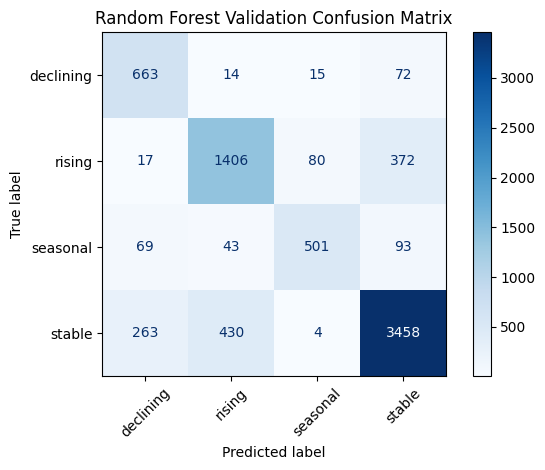

In [4]:
y_val_pred = rf.predict(X_val)

print(classification_report(y_val, y_val_pred, digits=3))

ConfusionMatrixDisplay.from_predictions(
    y_val,
    y_val_pred,
    xticks_rotation=45,
    cmap="Blues",
)
plt.title("Random Forest Validation Confusion Matrix")
plt.tight_layout()
plt.show()

## 4. Feature Importance

Random Forest importance is first calculated for each encoded model column, then aggregated back to original feature names. This avoids overstating one-hot encoded variables such as category, country, or traffic source as many separate factors.

In [5]:
encoded_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf.feature_importances_,
})

encoded_importance = encoded_importance.merge(feature_metadata, on="feature", how="left")

factor_importance = (
    encoded_importance.dropna(subset=["original_feature", "feature_group"])
    .groupby(["original_feature", "feature_group"], as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

top_factors = factor_importance.head(20).copy()

display(top_factors.round(4))

,original_feature,feature_group,importance
0,weekend_hashtag_boost,interactions,0.1893
1,rel_combo,engagement_observed,0.1176
2,share_rate_log,engagement_observed,0.0739
3,rel_share,engagement_observed,0.0724
4,share_hashtag_interaction,interactions,0.0704
5,likes_per_day,engagement_observed,0.0689
6,share_rate,engagement_observed,0.0684
7,views_per_day,engagement_observed,0.0489
8,like_rate_log,engagement_observed,0.0435
9,like_rate,engagement_observed,0.0362


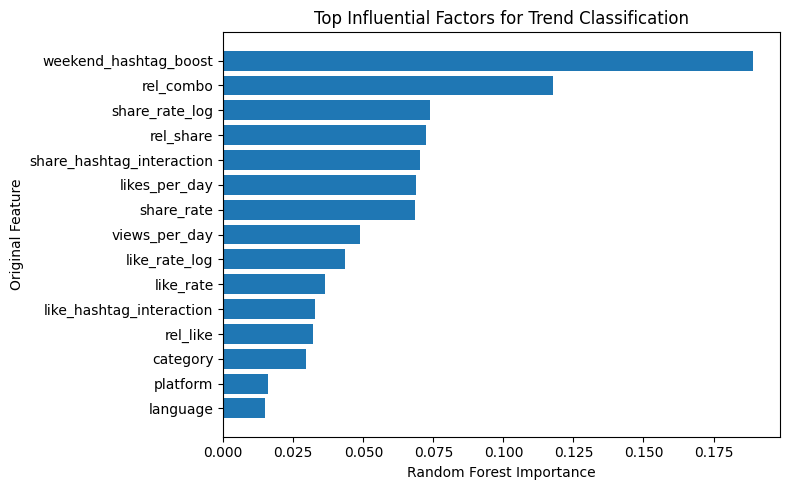

In [6]:
plot_factors = top_factors.head(15).sort_values("importance")

plt.figure(figsize=(8, 5))
plt.barh(plot_factors["original_feature"], plot_factors["importance"])
plt.xlabel("Random Forest Importance")
plt.ylabel("Original Feature")
plt.title("Top Influential Factors for Trend Classification")
plt.tight_layout()
plt.show()

### Feature Group Importance

The table below sums feature importance by broad feature group. It is useful for comparing engagement, metadata, creator, temporal, and basic content features at a higher level.

In [7]:
group_importance = (
    factor_importance.groupby("feature_group", as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

display(group_importance.round(4))

,feature_group,importance
0,engagement_observed,0.5899
1,interactions,0.2977
2,metadata,0.0947
3,creator,0.0142
4,content_basic,0.0035


## 5. Detailed Summary

Using the ML-preprocessed dataset gives much stronger predictive performance than the original CSV version. The original Random Forest reached only about 0.262 validation macro F1 and 0.245 test macro F1, which was close to chance for the roughly balanced four-class target. On the ML dataset, the Random Forest reaches 0.777 validation macro F1 and 0.782 test macro F1, with test accuracy around 0.810. This is also far above the ML majority baseline, which reaches 0.554 test accuracy but only 0.178 macro F1 because it predicts the dominant `stable` class.

The validation classification report shows useful performance across all four classes rather than only the majority class. The model performs best on `stable`, with validation F1 about 0.849, but it also performs reasonably on the minority classes: `declining` F1 about 0.747 and `seasonal` F1 about 0.767. This is important because the ML dataset is imbalanced, with `stable` making up about 55% of the training labels.

The most influential individual factors are mostly engineered engagement and interaction features. The top factors are `weekend_hashtag_boost`, `rel_combo`, `share_rate_log`, `rel_share`, `share_hashtag_interaction`, `likes_per_day`, `share_rate`, and `views_per_day`. Compared with the original CSV, where raw engagement variables such as `completion_rate`, `save_rate`, `creator_avg_views`, and `like_dislike_ratio` dominated but produced weak model performance, the ML version's engineered features appear to capture much stronger signal.

At the feature-group level, `engagement_observed` is still the largest source of Random Forest importance at about 0.590. However, the new `interactions` group is also highly important at about 0.298, while `metadata` contributes about 0.095. `creator` and `content_basic` contribute much less. This suggests that the ML dataset improves prediction mainly through engineered engagement rates and interaction terms rather than simple metadata alone.

Overall answer to RQ1: in the ML dataset, trend classification is most strongly influenced by engineered engagement and interaction features, especially `weekend_hashtag_boost`, relative engagement combinations, share-rate transformations, and hashtag interaction terms. Unlike the original CSV results, these importance rankings are supported by strong validation and test performance, so they can be reported with more confidence as predictive associations, while still not being interpreted as causal effects.